In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,  
    ReduceLROnPlateau)
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPU Available: []


In [2]:
import os
for split in ["train", "valid"]:
    split_path = os.path.join(
        r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2",
        split
    )
    print(f"\n========== {split.upper()} ==========")
    total = 0
    for plant in sorted(os.listdir(split_path)):
        plant_path = os.path.join(split_path, plant)
        if os.path.isdir(plant_path):
            plant_total = 0
            for disease in os.listdir(plant_path):
                disease_path = os.path.join(plant_path, disease)
                if os.path.isdir(disease_path):
                    count = len([
                        f for f in os.listdir(disease_path)
                        if f.lower().endswith((".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"))
                    ])
                    print(f"{plant} -> {disease}: {count}")
                    plant_total += count
            print(f"{plant} TOTAL: {plant_total}")
            total += plant_total
    print(f"\nTOTAL {split.upper()} IMAGES: {total}")


========== TRAIN ==========
Apple -> Apple Scab: 2016
Apple -> Black Rot: 1987
Apple -> Cedar Apple Rust: 1760
Apple -> Healthy: 2008
Apple TOTAL: 7771
Cherry -> Healthy: 1826
Cherry -> Powdery Mildew: 1683
Cherry TOTAL: 3509
Corn -> Common Rust: 1907
Corn -> Gray Leaf Spot: 1642
Corn -> Healthy: 1859
Corn -> Northern Leaf Blight: 1908
Corn TOTAL: 7316
Grape -> Black Rot: 1888
Grape -> Esca: 1920
Grape -> Healthy: 1692
Grape -> Leaf Blight: 1722
Grape TOTAL: 7222
Peach -> Bacterial Spot: 1838
Peach -> Healthy: 1728
Peach TOTAL: 3566
Pepper -> Bacterial Spot: 1913
Pepper -> Healthy: 1988
Pepper TOTAL: 3901
Potato -> Early Blight: 1939
Potato -> Healthy: 1824
Potato -> Late Blight: 1939
Potato TOTAL: 5702
Strawberry -> Healthy: 1824
Strawberry -> Leaf Scorch: 1774
Strawberry TOTAL: 3598
Tomato -> Bacterial Spot: 1702
Tomato -> Early Blight: 1920
Tomato -> Healthy: 1926
Tomato -> Late Blight: 1851
Tomato TOTAL: 7399

TOTAL TRAIN IMAGES: 49984

========== VALID ==========
Apple -> Apple S

In [3]:
TRAIN_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\train"
VALID_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Train Directory:", TRAIN_DIR)
print("Validation Directory:", VALID_DIR)

Train Directory: D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\train
Validation Directory: D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\valid


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(
    rescale=1./255
)
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)
valid_data = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
print("Training Images :", train_data.samples)
print("Validation Images :", valid_data.samples)
print("Number of Classes :", train_data.num_classes)
print("Classes :")
print(train_data.class_indices)

Found 49984 images belonging to 9 classes.
Found 12494 images belonging to 9 classes.
Training Images : 49984
Validation Images : 12494
Number of Classes : 9
Classes :
{'Apple': 0, 'Cherry': 1, 'Corn': 2, 'Grape': 3, 'Peach': 4, 'Pepper': 5, 'Potato': 6, 'Strawberry': 7, 'Tomato': 8}


In [5]:
print("Train classes :", train_data.num_classes)
print("Valid classes :", valid_data.num_classes)

print("\nClass mapping:")
for name, index in train_data.class_indices.items():
    print(index, "->", name)

Train classes : 9
Valid classes : 9

Class mapping:
0 -> Apple
1 -> Cherry
2 -> Corn
3 -> Grape
4 -> Peach
5 -> Pepper
6 -> Potato
7 -> Strawberry
8 -> Tomato


In [6]:
import os
TRAIN_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\train"
VALID_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\valid"
train_classes = []
valid_classes = []
for crop in sorted(os.listdir(TRAIN_DIR)):
    crop_path = os.path.join(TRAIN_DIR, crop)

    if os.path.isdir(crop_path):
        for disease in sorted(os.listdir(crop_path)):
            disease_path = os.path.join(crop_path, disease)

            if os.path.isdir(disease_path):
                train_classes.append(f"{crop} - {disease}")

for crop in sorted(os.listdir(VALID_DIR)):
    crop_path = os.path.join(VALID_DIR, crop)

    if os.path.isdir(crop_path):
        for disease in sorted(os.listdir(crop_path)):
            disease_path = os.path.join(crop_path, disease)

            if os.path.isdir(disease_path):
                valid_classes.append(f"{crop} - {disease}")

print("Train Classes:", len(train_classes))
print("Validation Classes:", len(valid_classes))

print("\n===== TRAIN CLASSES =====")
for i, cls in enumerate(train_classes):
    print(i, ":", cls)

print("\n===== VALID CLASSES =====")
for i, cls in enumerate(valid_classes):
    print(i, ":", cls)

Train Classes: 27
Validation Classes: 27

===== TRAIN CLASSES =====
0 : Apple - Apple Scab
1 : Apple - Black Rot
2 : Apple - Cedar Apple Rust
3 : Apple - Healthy
4 : Cherry - Healthy
5 : Cherry - Powdery Mildew
6 : Corn - Common Rust
7 : Corn - Gray Leaf Spot
8 : Corn - Healthy
9 : Corn - Northern Leaf Blight
10 : Grape - Black Rot
11 : Grape - Esca
12 : Grape - Healthy
13 : Grape - Leaf Blight
14 : Peach - Bacterial Spot
15 : Peach - Healthy
16 : Pepper - Bacterial Spot
17 : Pepper - Healthy
18 : Potato - Early Blight
19 : Potato - Healthy
20 : Potato - Late Blight
21 : Strawberry - Healthy
22 : Strawberry - Leaf Scorch
23 : Tomato - Bacterial Spot
24 : Tomato - Early Blight
25 : Tomato - Healthy
26 : Tomato - Late Blight

===== VALID CLASSES =====
0 : Apple - Apple Scab
1 : Apple - Black Rot
2 : Apple - Cedar Apple Rust
3 : Apple - Healthy
4 : Cherry - Healthy
5 : Cherry - Powdery Mildew
6 : Corn - Common Rust
7 : Corn - Gray Leaf Spot
8 : Corn - Healthy
9 : Corn - Northern Leaf Blig

In [7]:
from collections import Counter
import os
train_counts = {}
for crop in sorted(os.listdir(TRAIN_DIR)):
    crop_path = os.path.join(TRAIN_DIR, crop)

    if not os.path.isdir(crop_path):
        continue

    for disease in sorted(os.listdir(crop_path)):
        disease_path = os.path.join(crop_path, disease)

        if os.path.isdir(disease_path):
            count = len([
                f for f in os.listdir(disease_path)
                if os.path.isfile(os.path.join(disease_path, f))
            ])

            train_counts[f"{crop} - {disease}"] = count

print("Total classes:", len(train_counts))
print("Total training images:", sum(train_counts.values()))

for cls, count in train_counts.items():
    print(f"{cls}: {count}")

Total classes: 27
Total training images: 49984
Apple - Apple Scab: 2016
Apple - Black Rot: 1987
Apple - Cedar Apple Rust: 1760
Apple - Healthy: 2008
Cherry - Healthy: 1826
Cherry - Powdery Mildew: 1683
Corn - Common Rust: 1907
Corn - Gray Leaf Spot: 1642
Corn - Healthy: 1859
Corn - Northern Leaf Blight: 1908
Grape - Black Rot: 1888
Grape - Esca: 1920
Grape - Healthy: 1692
Grape - Leaf Blight: 1722
Peach - Bacterial Spot: 1838
Peach - Healthy: 1728
Pepper - Bacterial Spot: 1913
Pepper - Healthy: 1988
Potato - Early Blight: 1939
Potato - Healthy: 1824
Potato - Late Blight: 1939
Strawberry - Healthy: 1824
Strawberry - Leaf Scorch: 1774
Tomato - Bacterial Spot: 1702
Tomato - Early Blight: 1920
Tomato - Healthy: 1926
Tomato - Late Blight: 1851


In [8]:
from pathlib import Path
def collect_images_and_labels(root_dir):
    root = Path(root_dir)

    image_paths = []
    labels = []

    for crop_dir in sorted(root.iterdir()):
        if not crop_dir.is_dir():
            continue

        for disease_dir in sorted(crop_dir.iterdir()):
            if not disease_dir.is_dir():
                continue

            label = f"{crop_dir.name} - {disease_dir.name}"

            for image_path in disease_dir.iterdir():
                if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    image_paths.append(str(image_path))
                    labels.append(label)

    return image_paths, labels


train_paths, train_labels = collect_images_and_labels(TRAIN_DIR)
valid_paths, valid_labels = collect_images_and_labels(VALID_DIR)

print("Training images :", len(train_paths))
print("Validation images :", len(valid_paths))
print("Training classes :", len(set(train_labels)))
print("Validation classes :", len(set(valid_labels)))

Training images : 49984
Validation images : 12494
Training classes : 27
Validation classes : 27


In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
valid_labels_encoded = label_encoder.transform(valid_labels)

NUM_CLASSES = len(label_encoder.classes_)

print("Number of Classes:", NUM_CLASSES)

print("\nClass Mapping:")
for index, class_name in enumerate(label_encoder.classes_):
    print(index, "->", class_name)

print("\nEncoded label range:")
print("Train:", train_labels_encoded.min(), "to", train_labels_encoded.max())
print("Valid:", valid_labels_encoded.min(), "to", valid_labels_encoded.max())

Number of Classes: 27

Class Mapping:
0 -> Apple - Apple Scab
1 -> Apple - Black Rot
2 -> Apple - Cedar Apple Rust
3 -> Apple - Healthy
4 -> Cherry - Healthy
5 -> Cherry - Powdery Mildew
6 -> Corn - Common Rust
7 -> Corn - Gray Leaf Spot
8 -> Corn - Healthy
9 -> Corn - Northern Leaf Blight
10 -> Grape - Black Rot
11 -> Grape - Esca
12 -> Grape - Healthy
13 -> Grape - Leaf Blight
14 -> Peach - Bacterial Spot
15 -> Peach - Healthy
16 -> Pepper - Bacterial Spot
17 -> Pepper - Healthy
18 -> Potato - Early Blight
19 -> Potato - Healthy
20 -> Potato - Late Blight
21 -> Strawberry - Healthy
22 -> Strawberry - Leaf Scorch
23 -> Tomato - Bacterial Spot
24 -> Tomato - Early Blight
25 -> Tomato - Healthy
26 -> Tomato - Late Blight

Encoded label range:
Train: 0 to 26
Valid: 0 to 26


In [10]:
AUTOTUNE = 1
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels_encoded)
)
valid_ds = tf.data.Dataset.from_tensor_slices(
    (valid_paths, valid_labels_encoded)
)

train_ds = train_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=1
)

valid_ds = valid_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)
train_ds = train_ds.shuffle(buffer_size=1000)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(1)
valid_ds = valid_ds.batch(BATCH_SIZE).prefetch(1)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [11]:
class_names = label_encoder.classes_
for images, labels in train_ds.take(1):
    print("Batch image shape :", images.shape)
    print("Batch label shape :", labels.shape)
    print("\nFirst 10 image labels:")
    for label in labels[:10]:
        index = int(label.numpy())
        print(index, "->", class_names[index])

Batch image shape : (32, 224, 224, 3)
Batch label shape : (32,)

First 10 image labels:
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab


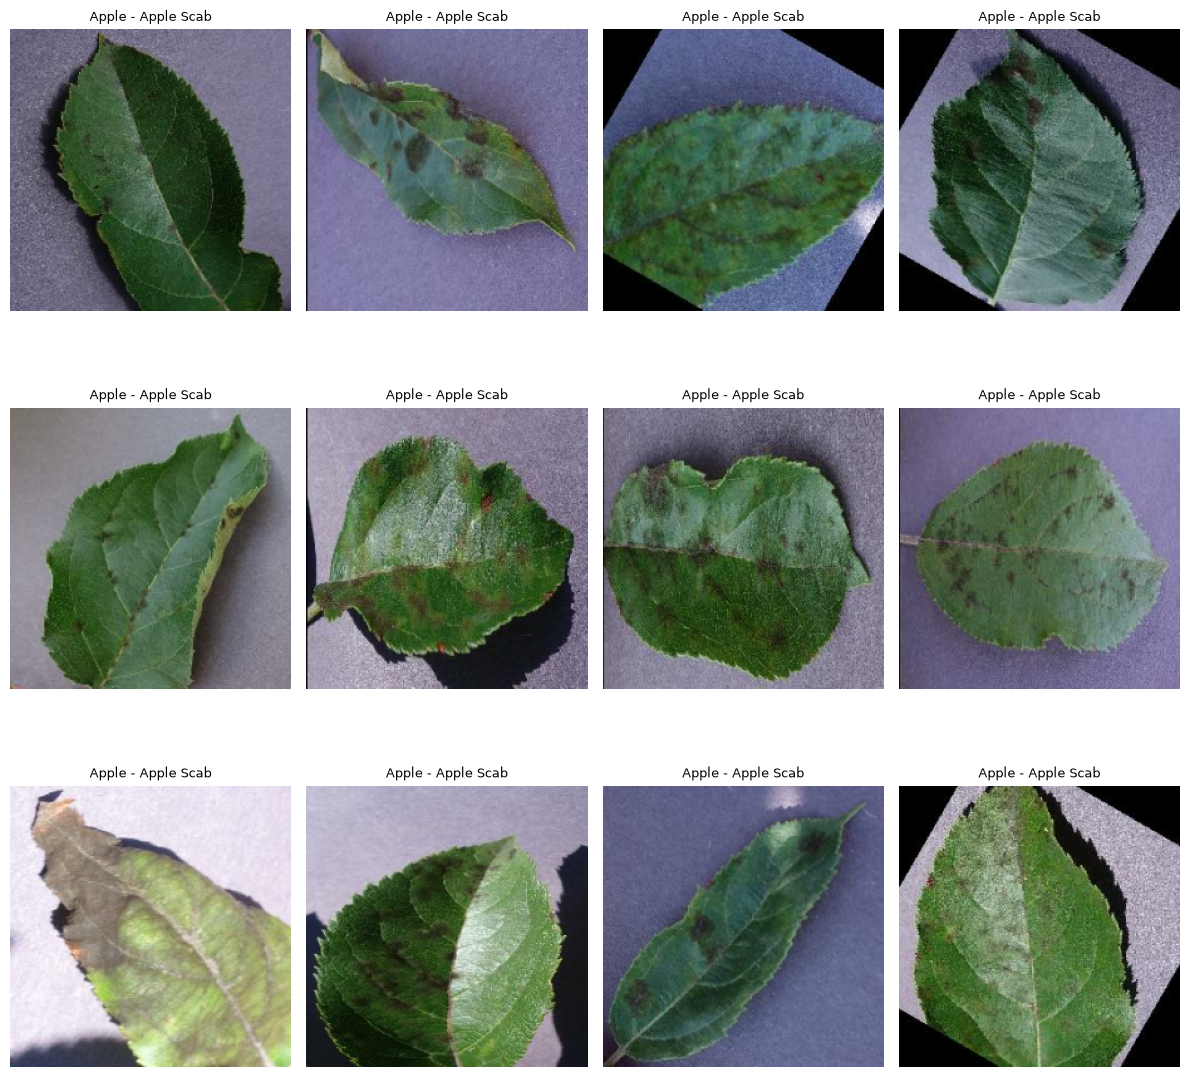

In [12]:
class_names = label_encoder.classes_
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 12))
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        label_index = int(labels[i].numpy())
        plt.title(class_names[label_index], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

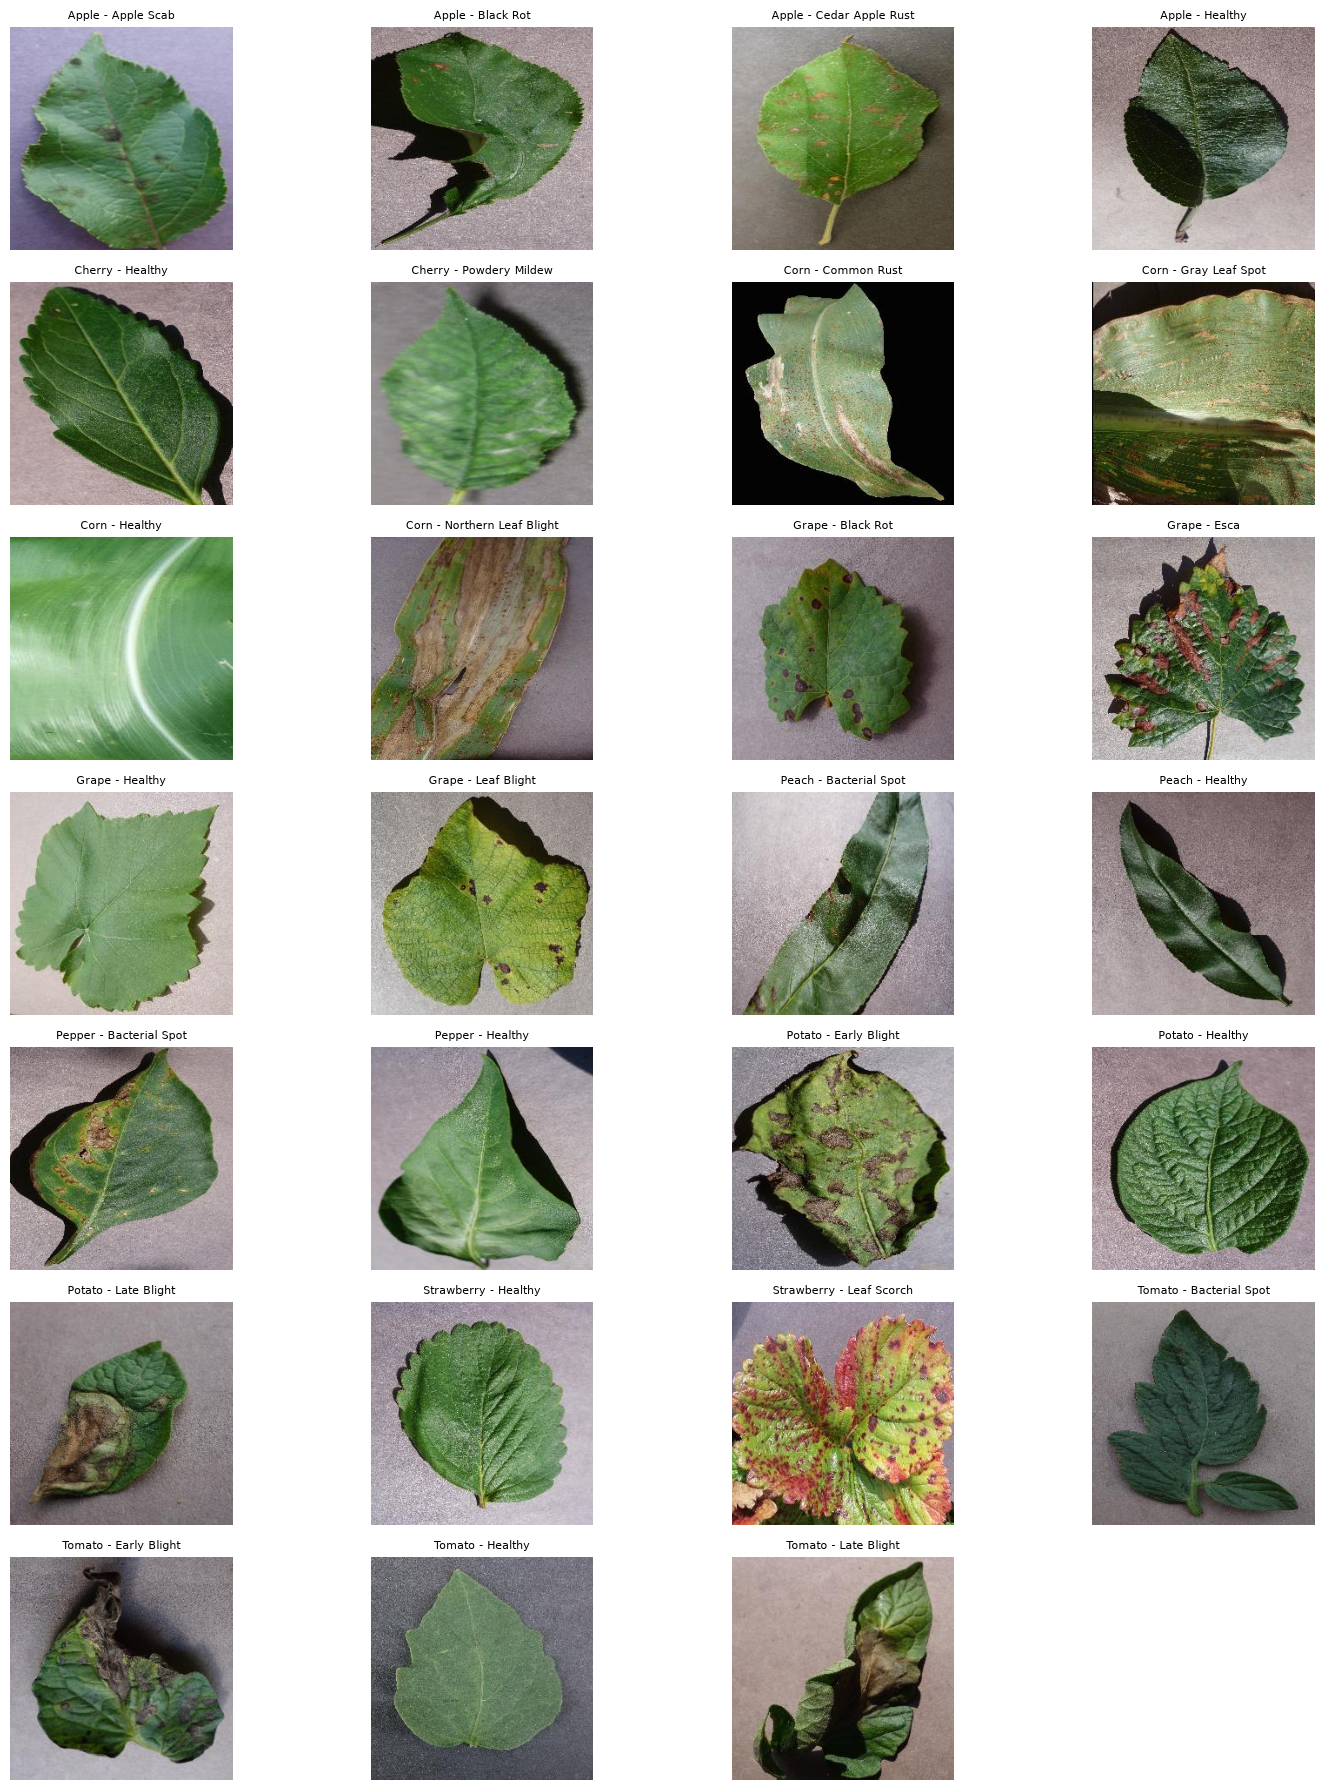

In [13]:
from PIL import Image
class_names = label_encoder.classes_
plt.figure(figsize=(15, 18))
for class_id in range(len(class_names)):
    indices = np.where(np.array(train_labels_encoded) == class_id)[0]
    if len(indices) == 0:
        continue
    image_path = train_paths[indices[0]]
    image = Image.open(image_path).convert("RGB")
    plt.subplot(7, 4, class_id + 1)
    plt.imshow(image)
    plt.title(class_names[class_id], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.10)])
print("Data augmentation created successfully.")

Data augmentation created successfully.


In [15]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet")
base_model.trainable = False
print("MobileNetV2 loaded successfully.")
print("Total layers :", len(base_model.layers))
print("Trainable    :", base_model.trainable)

MobileNetV2 loaded successfully.
Total layers : 154
Trainable    : False


In [16]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# Convert [0, 1] pixels to [-1, 1] for MobileNetV2
x = layers.Rescaling(2.0, offset=-1.0)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │        34,587 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,292,571 (8.75 MB)

 Trainable params: 34,587 (135.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully.")

Model compiled successfully.


In [18]:
checkpoint_path = r"D:\Capstone Project\Farmer---Guide---AI\Model\disease_mobilenetv2_best.keras"
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )]
print("Callbacks created successfully.")
print("Checkpoint:", checkpoint_path)

Callbacks created successfully.
Checkpoint: D:\Capstone Project\Farmer---Guide---AI\Model\disease_mobilenetv2_best.keras


In [19]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=callbacks)

Epoch 1/10


d:\Capstone Project\Farmer---Guide---AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1475s 936ms/step - accuracy: 0.5933 - loss: 1.7871 - val_accuracy: 0.0433 - val_loss: 5.0361 - learning_rate: 1.0000e-04
Epoch 2/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1460s 930ms/step - accuracy: 0.7664 - loss: 0.9131 - val_accuracy: 0.1316 - val_loss: 3.3946 - learning_rate: 1.0000e-04
Epoch 3/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1418s 905ms/step - accuracy: 0.8445 - loss: 0.5648 - val_accuracy: 0.2431 - val_loss: 2.3977 - learning_rate: 1.0000e-04
Epoch 4/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1683s 1s/step - accuracy: 0.8841 - loss: 0.4095 - val_accuracy: 0.3411 - val_loss: 1.9939 - learning_rate: 1.0000e-04
Epoch 5/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1435s 916ms/step - accuracy: 0.9060 - loss: 0.3217 - val_accuracy: 0.4561 - val_loss: 1.6317 - learning_rate: 1.0000e-04
Epoch 6/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 22075s 14s/step - accuracy: 0.9190 - loss: 0.2709 - val_accuracy: 0.5400 - val_loss: 1.3591 - learning_rate: 1.0000e-04
Epoch 7/10
1562/1562 ━━━━━━━━━━━━━━━━

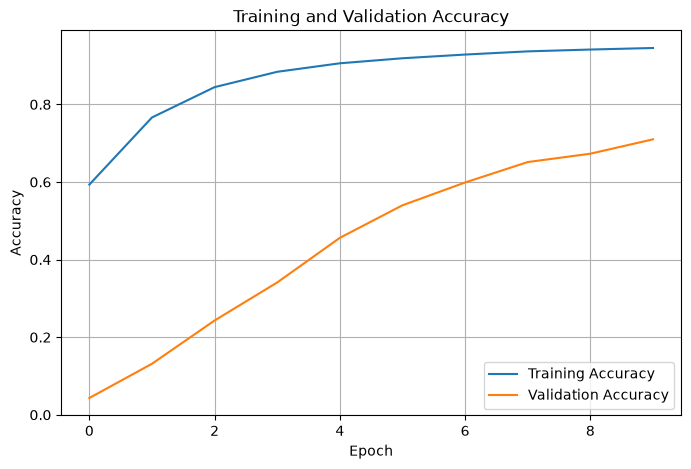

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

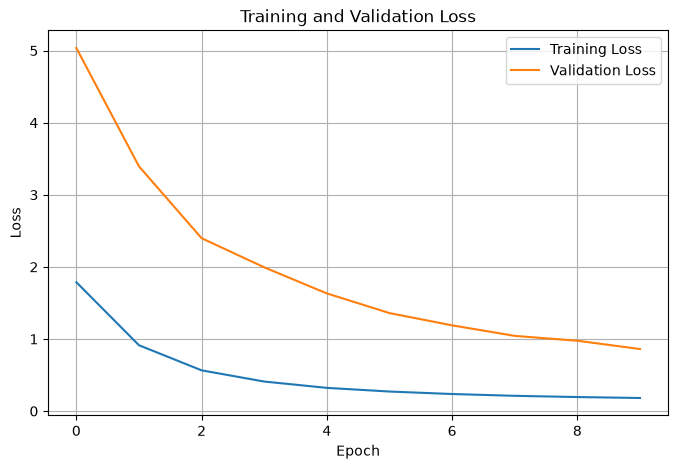

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"]) * 100
best_train_accuracy = history.history["accuracy"][best_epoch - 1] * 100

print("=" * 50)
print("BEST EPOCH :", best_epoch)
print("BEST TRAINING ACCURACY :", best_train_accuracy)
print("BEST VALIDATION ACCURACY :", best_val_accuracy)
print("=" * 50)

BEST EPOCH : 10
BEST TRAINING ACCURACY : 94.54225301742554
BEST VALIDATION ACCURACY : 71.00207805633545


In [23]:
val_loss, val_accuracy = model.evaluate(valid_ds)

print("=" * 50)
print("Validation Loss :", val_loss)
print("Validation Accuracy :", val_accuracy * 100)
print("=" * 50)

391/391 ━━━━━━━━━━━━━━━━━━━━ 214s 547ms/step - accuracy: 0.7100 - loss: 0.8604
Validation Loss : 0.8603936433792114
Validation Accuracy : 71.00207805633545


In [24]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

Classification Report:

                             precision    recall  f1-score   support

         Apple - Apple Scab     0.9922    0.2540    0.4044       504
          Apple - Black Rot     0.9957    0.4628    0.6319       497
   Apple - Cedar Apple Rust     0.9722    0.5568    0.7081       440
            Apple - Healthy     0.9580    0.6355    0.7641       502
           Cherry - Healthy     0.9769    0.7434    0.8443       456
    Cherry - Powdery Mildew     0.9961    0.6143    0.7599       420
         Corn - Common Rust     0.9953    0.8847    0.9367       477
      Corn - Gray Leaf Spot     1.0000    0.3537    0.5225       410
             Corn - Healthy     1.0000    0.9914    0.9957       465
Corn - Northern Leaf Blight     0.6169    0.9790    0.7569       477
          Grape - Black Rot     0.9973    0.7691    0.8684       472
               Grape - Esca     0.8748    0.9896    0.9286       480
            Grape - Healthy     0.9909    0.7754    0.8700       423
        G

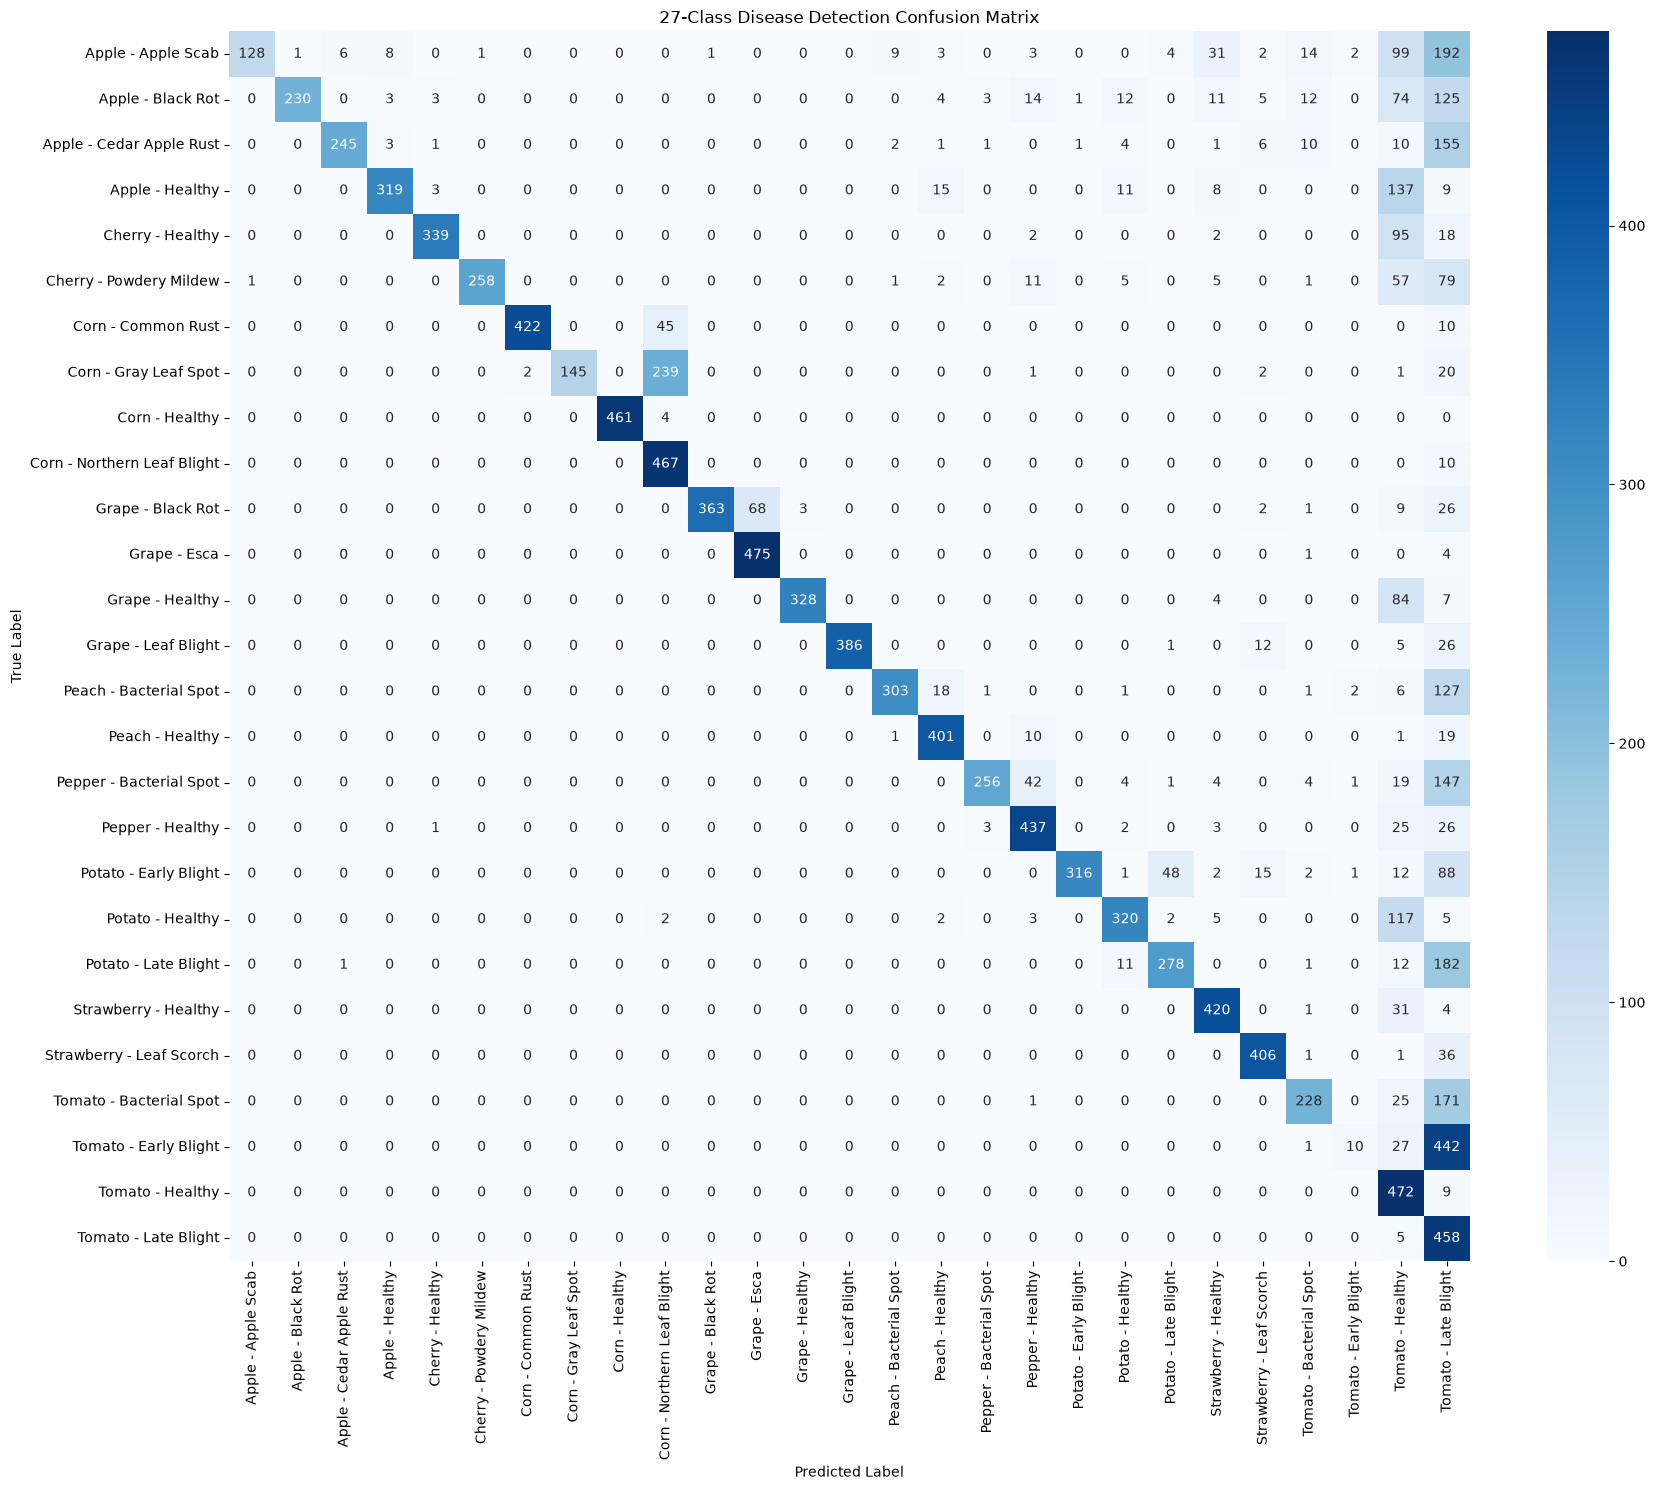

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("27-Class Disease Detection Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
# Copy confusion matrix
cm_no_diag = cm.copy()

# Correct predictions ko remove karo
np.fill_diagonal(cm_no_diag, 0)

# Highest confusion pairs
confusion_pairs = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm_no_diag[i, j] > 0:
            confusion_pairs.append(
                (cm_no_diag[i, j], class_names[i], class_names[j])
            )

# Highest se lowest sort
confusion_pairs = sorted(
    confusion_pairs,
    key=lambda x: x[0],
    reverse=True
)

print("Top 20 Confusion Pairs:\n")

for count, actual, predicted in confusion_pairs[:20]:
    print(f"{actual}  -->  {predicted} : {count}")

Top 20 Confusion Pairs:

Tomato - Early Blight  -->  Tomato - Late Blight : 442
Corn - Gray Leaf Spot  -->  Corn - Northern Leaf Blight : 239
Apple - Apple Scab  -->  Tomato - Late Blight : 192
Potato - Late Blight  -->  Tomato - Late Blight : 182
Tomato - Bacterial Spot  -->  Tomato - Late Blight : 171
Apple - Cedar Apple Rust  -->  Tomato - Late Blight : 155
Pepper - Bacterial Spot  -->  Tomato - Late Blight : 147
Apple - Healthy  -->  Tomato - Healthy : 137
Peach - Bacterial Spot  -->  Tomato - Late Blight : 127
Apple - Black Rot  -->  Tomato - Late Blight : 125
Potato - Healthy  -->  Tomato - Healthy : 117
Apple - Apple Scab  -->  Tomato - Healthy : 99
Cherry - Healthy  -->  Tomato - Healthy : 95
Potato - Early Blight  -->  Tomato - Late Blight : 88
Grape - Healthy  -->  Tomato - Healthy : 84
Cherry - Powdery Mildew  -->  Tomato - Late Blight : 79
Apple - Black Rot  -->  Tomato - Healthy : 74
Grape - Black Rot  -->  Grape - Esca : 68
Cherry - Powdery Mildew  -->  Tomato - Healthy :

In [27]:
from tensorflow.keras.utils import load_img, img_to_array

test_dir = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\test"

image_files = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total test images:", len(image_files))
print("\nPredictions:\n")

for filename in image_files:

    image_path = os.path.join(test_dir, filename)

    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(
        img_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    predicted_class = class_names[predicted_index]

    print(
        f"{filename:35} -> "
        f"{predicted_class:35} "
        f"Confidence: {confidence:.2f}%"
    )

Total test images: 39

Predictions:

AppleCedarRust1.JPG                 -> Apple - Cedar Apple Rust            Confidence: 50.66%
AppleCedarRust2.JPG                 -> Apple - Cedar Apple Rust            Confidence: 80.21%
AppleCedarRust3.JPG                 -> Tomato - Late Blight                Confidence: 94.37%
AppleCedarRust4.JPG                 -> Apple - Cedar Apple Rust            Confidence: 68.22%
AppleScab1.JPG                      -> Tomato - Late Blight                Confidence: 42.27%
AppleScab2.JPG                      -> Tomato - Late Blight                Confidence: 43.61%
AppleScab3.JPG                      -> Tomato - Late Blight                Confidence: 56.59%
CherryHealthy.JPG                   -> Tomato - Late Blight                Confidence: 59.43%
CherryPowderyMildew.JPG             -> Cherry - Powdery Mildew             Confidence: 53.90%
CornCommonRust1.JPG                 -> Corn - Common Rust                  Confidence: 89.95%
CornCommonRust2.JPG    

In [28]:
print("Class-wise Validation Accuracy:\n")

for i, class_name in enumerate(class_names):

    total = np.sum(y_true == i)
    correct = np.sum((y_true == i) & (y_pred == i))

    accuracy = correct / total if total > 0 else 0

    print(
        f"{class_name:35} "
        f"{correct:4}/{total:<4} "
        f"Accuracy: {accuracy*100:6.2f}%"
    )

Class-wise Validation Accuracy:

Apple - Apple Scab                   128/504  Accuracy:  25.40%
Apple - Black Rot                    230/497  Accuracy:  46.28%
Apple - Cedar Apple Rust             245/440  Accuracy:  55.68%
Apple - Healthy                      319/502  Accuracy:  63.55%
Cherry - Healthy                     339/456  Accuracy:  74.34%
Cherry - Powdery Mildew              258/420  Accuracy:  61.43%
Corn - Common Rust                   422/477  Accuracy:  88.47%
Corn - Gray Leaf Spot                145/410  Accuracy:  35.37%
Corn - Healthy                       461/465  Accuracy:  99.14%
Corn - Northern Leaf Blight          467/477  Accuracy:  97.90%
Grape - Black Rot                    363/472  Accuracy:  76.91%
Grape - Esca                         475/480  Accuracy:  98.96%
Grape - Healthy                      328/423  Accuracy:  77.54%
Grape - Leaf Blight                  386/430  Accuracy:  89.77%
Peach - Bacterial Spot               303/459  Accuracy:  66.01%
Peach -

In [31]:
print("Training Class Counts:\n")

# Unique labels and their counts
unique_labels, label_counts = np.unique(
    train_labels,
    return_counts=True
)

for label, count in zip(unique_labels, label_counts):
    print(f"{label} : {count}")

print("\n--- Tomato Blight Counts ---")

# Check whether labels are numeric or text
print("train_labels dtype:", np.array(train_labels).dtype)

# Tomato class names
early_name = "Tomato - Early Blight"
late_name = "Tomato - Late Blight"

# Find their positions in class_names
early_idx = np.where(
    np.array(class_names) == early_name
)[0][0]

late_idx = np.where(
    np.array(class_names) == late_name
)[0][0]

print("Tomato Early Blight class index:", early_idx)
print("Tomato Late Blight class index:", late_idx)

# Counts
early_count = np.sum(np.array(train_labels) == early_idx)
late_count = np.sum(np.array(train_labels) == late_idx)

print("Tomato Early Blight:", early_count)
print("Tomato Late Blight:", late_count)

Training Class Counts:

Apple - Apple Scab : 2016
Apple - Black Rot : 1987
Apple - Cedar Apple Rust : 1760
Apple - Healthy : 2008
Cherry - Healthy : 1826
Cherry - Powdery Mildew : 1683
Corn - Common Rust : 1907
Corn - Gray Leaf Spot : 1642
Corn - Healthy : 1859
Corn - Northern Leaf Blight : 1908
Grape - Black Rot : 1888
Grape - Esca : 1920
Grape - Healthy : 1692
Grape - Leaf Blight : 1722
Peach - Bacterial Spot : 1838
Peach - Healthy : 1728
Pepper - Bacterial Spot : 1913
Pepper - Healthy : 1988
Potato - Early Blight : 1939
Potato - Healthy : 1824
Potato - Late Blight : 1939
Strawberry - Healthy : 1824
Strawberry - Leaf Scorch : 1774
Tomato - Bacterial Spot : 1702
Tomato - Early Blight : 1920
Tomato - Healthy : 1926
Tomato - Late Blight : 1851

--- Tomato Blight Counts ---
train_labels dtype: <U27
Tomato Early Blight class index: 24
Tomato Late Blight class index: 26
Tomato Early Blight: 0
Tomato Late Blight: 0


In [32]:
train_labels_array = np.array(train_labels)

early_name = "Tomato - Early Blight"
late_name = "Tomato - Late Blight"

early_count = np.sum(train_labels_array == early_name)
late_count = np.sum(train_labels_array == late_name)

print("Tomato Early Blight:", early_count)
print("Tomato Late Blight:", late_count)

print("\nTomato class distribution:")
print(
    "Early Blight :",
    early_count
)

print(
    "Late Blight  :",
    late_count
)

Tomato Early Blight: 1920
Tomato Late Blight: 1851

Tomato class distribution:
Early Blight : 1920
Late Blight  : 1851


Early Blight images: 1920
Late Blight images : 1851


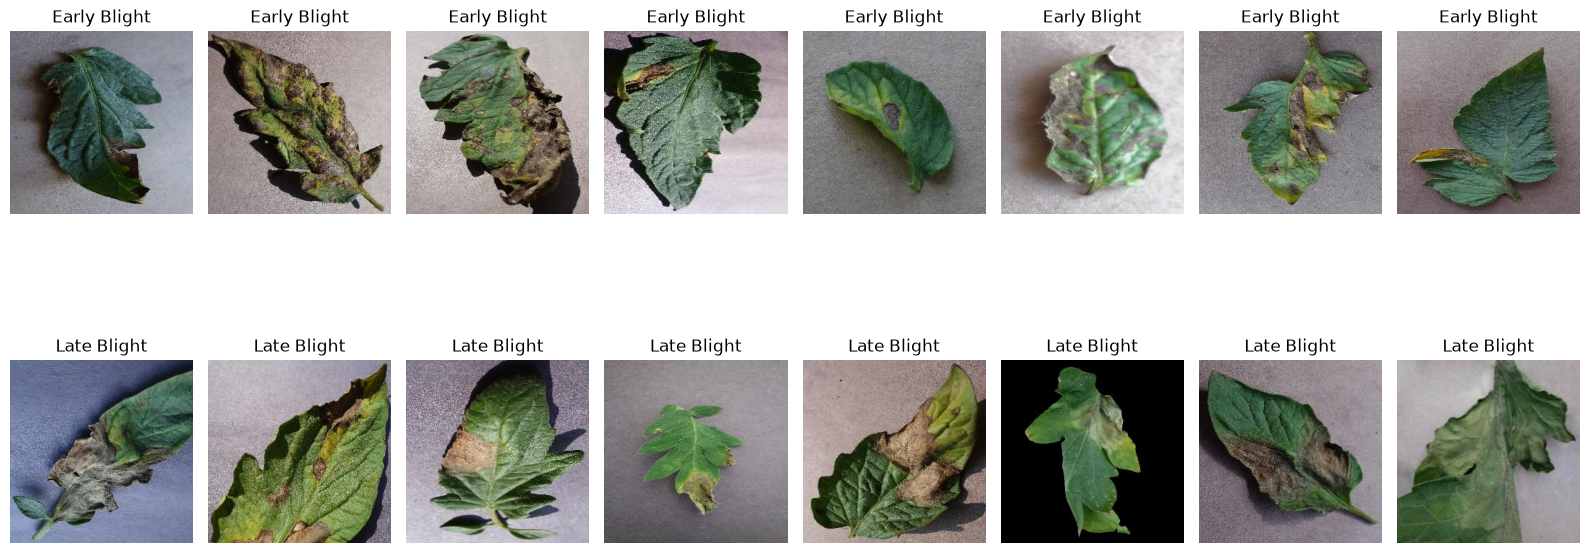

In [33]:
import random

train_labels_array = np.array(train_labels)

early_indices = np.where(
    train_labels_array == "Tomato - Early Blight"
)[0]

late_indices = np.where(
    train_labels_array == "Tomato - Late Blight"
)[0]

print("Early Blight images:", len(early_indices))
print("Late Blight images :", len(late_indices))

early_samples = random.sample(
    list(early_indices),
    min(8, len(early_indices))
)

late_samples = random.sample(
    list(late_indices),
    min(8, len(late_indices))
)

plt.figure(figsize=(16, 8))

for i, idx in enumerate(early_samples):
    img = plt.imread(train_paths[idx])

    plt.subplot(2, 8, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Early Blight")

for i, idx in enumerate(late_samples):
    img = plt.imread(train_paths[idx])

    plt.subplot(2, 8, i + 9)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Late Blight")

plt.tight_layout()
plt.show()

In [34]:
early_idx = np.where(
    np.array(class_names) == "Tomato - Early Blight"
)[0][0]

late_idx = np.where(
    np.array(class_names) == "Tomato - Late Blight"
)[0][0]

print("Tomato Early Blight index:", early_idx)
print("Tomato Late Blight index :", late_idx)

print("\nEarly Blight Validation Predictions:\n")

count = 0

for images, labels in valid_ds:

    predictions = model.predict(images, verbose=0)

    labels_np = labels.numpy()

    # Only actual Early Blight images
    for i in range(len(labels_np)):

        if labels_np[i] == early_idx:

            probs = predictions[i]

            top_indices = np.argsort(probs)[::-1][:5]

            print(f"\nImage {count + 1}")

            for idx in top_indices:
                print(
                    f"{class_names[idx]:35} "
                    f"{probs[idx] * 100:.2f}%"
                )

            count += 1

            # First 10 samples only
            if count >= 10:
                break

    if count >= 10:
        break

Tomato Early Blight index: 24
Tomato Late Blight index : 26

Early Blight Validation Predictions:


Image 1
Tomato - Bacterial Spot             43.40%
Tomato - Late Blight                23.23%
Apple - Apple Scab                  9.99%
Tomato - Early Blight               7.30%
Pepper - Bacterial Spot             6.00%

Image 2
Tomato - Late Blight                81.02%
Tomato - Early Blight               13.18%
Tomato - Bacterial Spot             2.10%
Tomato - Healthy                    1.37%
Strawberry - Leaf Scorch            1.24%

Image 3
Tomato - Late Blight                87.61%
Tomato - Bacterial Spot             6.59%
Tomato - Early Blight               4.06%
Tomato - Healthy                    1.42%
Strawberry - Leaf Scorch            0.08%

Image 4
Tomato - Late Blight                60.46%
Tomato - Healthy                    20.55%
Tomato - Early Blight               9.34%
Tomato - Bacterial Spot             6.89%
Grape - Esca                        0.87%

Image 5
Tomato - 